In [662]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import LightSource
from matplotlib.colors import LightSource
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

from data.data_utils import load_all
from data.dataset import RecDataset

In [700]:
model_title_name = 'FedNCF'
model_name = "ncf"
dataset_path = "../data/datasets/"
dataset = "filmtrust"
method = "original"
task_name = "fedrecgel-both_rho0.00"
target_model = "epoch93.pth"
device = "cuda:0"

In [705]:
model_title_name = 'FedRecGEL'
model_name = "ncf"
dataset_path = "../data/datasets/"
dataset = "filmtrust"
method = "original"
task_name = "fedrecgel-ns2e-2-sh0.00"
target_model = "epoch98.pth"
device = "cuda:0"

In [711]:
model_title_name = 'FedNCF'
model_name = "ncf"
dataset_path = "../data/datasets/"
dataset = "lastfm_2k"
method = "original"
task_name = "fedrecgel-both_rho0.00"
target_model = "epoch99.pth"
device = "cuda:0"

In [716]:
model_title_name = 'FedRecGEL'
model_name = "ncf"
dataset_path = "../data/datasets/"
dataset = "lastfm_2k"
method = "original"
task_name = "fedrecgel-both_rho0.01"
target_model = "epoch99.pth"
device = "cuda:0"

In [721]:
model_title_name = 'FedNCF'
model_name = "ncf"
dataset_path = "../data/datasets/"
dataset = "amazon_video"
method = "original"
task_name = "fedrecgel-both_rho0.00"
target_model = "epoch59.pth"
device = "cuda:0"

In [726]:
model_title_name = 'FedRecGEL'
model_name = "ncf"
dataset_path = "../data/datasets/"
dataset = "amazon_video"
method = "original"
task_name = "fedrecgel-ns0.2-sh1e-2"
target_model = "epoch74.pth"
device = "cuda:0"

In [689]:
model_title_name = 'FedNCF'
model_name = "ncf"
dataset_path = "../data/datasets/"
dataset = "qb_article"
method = "original"
task_name = "fedrecgel-both_rho0.00"
target_model = "epoch99.pth"
device = "cuda:0"

In [695]:
model_title_name = 'FedRecGEL'
model_name = "ncf"
dataset_path = "../data/datasets/"
dataset = "qb_article"
method = "original"
task_name = "fedrecgel-ns5e-2-sh0.02"
target_model = "epoch98.pth"
device = "cuda:0"

In [727]:
alpha_min = -0.001
alpha_max = 0.001
beta_min = -0.001
beta_max = 0.001
grid_size = 5
lanscape_save_folder = '../exp_results/landscape/'

In [ ]:
def construct_weight_path_wocheck(task_name, target_model):
    path = 'weights' if task_name == 'default' else f'weights-{task_name}'
    weight_path = os.path.join(save_path, path)
    weight_path = os.path.join(weight_path, target_model)
    return weight_path

In [ ]:
save_path = f'../exp_results/{model_name}/{dataset}/{method}/'

model_path = construct_weight_path_wocheck(task_name, target_model)
if not os.path.exists(model_path):
    print(f'Target model path {model_path} does not exist')

model = torch.load(model_path, map_location='cpu', weights_only=False)

In [ ]:
class PortableArgs:
    def __init__(self, dataset_path, dataset):
        self.dataset_path = dataset_path
        self.dataset = dataset

In [ ]:
auxiliary_args = PortableArgs(dataset_path, dataset)
train_data, _, user_num, item_num, train_mat = load_all(auxiliary_args)
train_dataset = RecDataset(train_data, user_num, item_num, train_mat, 1, True, model_name)
train_dataset.ng_sample()
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=4)

In [ ]:
def calculate_total_loss(model, train_loader, device):
    model.eval()
    loss_fn = nn.BCEWithLogitsLoss()

    total_loss_list = []
    with torch.no_grad():
        for user, item, label in train_loader:
            user, item, label = user.to(device), item.to(device), label.to(device)
            pred = model(user, item)
            loss = loss_fn(pred, label.float())
            total_loss_list.append(loss.item())

    return sum(total_loss_list) / len(total_loss_list)

In [ ]:
def get_shared_params(model):
    modules = [model.embed_item_gmf, model.embed_item_mlp, model.mlp_layers, model.predict_layer]
    params = [p for m in modules for p in m.parameters() if p.requires_grad]
    return params

In [ ]:
@torch.no_grad()
def sample_direction_like(params, mean=1.0, std=1.0, device='cpu'):
    dirs = [torch.randn_like(p).mul_(std).add_(mean).to(device) for p in params]
    norm = torch.sqrt(sum((d ** 2).sum() for d in dirs))
    dirs = [d / (norm + 1e-12) for d in dirs]
    return dirs

In [ ]:
@torch.no_grad()
def set_params_with_perturb(params, orig, dirs1, a, dirs2, b):
    for p, p0, d1, d2 in zip(params, orig, dirs1, dirs2):
        p.copy_(p0 + a * d1 + b * d2)

In [ ]:
model = model.to(device)

shared_params = get_shared_params(model)
orig = [p.detach().clone() for p in shared_params]
d1 = sample_direction_like(shared_params, mean=1.0, std=1.0, device=device)
d2 = sample_direction_like(shared_params, mean=1.0, std=1.0, device=device)

alphas = torch.linspace(alpha_min, alpha_max, grid_size).tolist()
betas = torch.linspace(beta_min, beta_max, grid_size).tolist()
loss_mat = np.zeros((grid_size, grid_size), dtype=np.float64)

with torch.no_grad():
    for i, a in enumerate(tqdm(alphas, desc='alpha', position=0, leave=True)):
        for j, b in enumerate(betas):
            set_params_with_perturb(shared_params, orig, d1, a, d2, b)
            loss_val = calculate_total_loss(model, train_loader, device)
            loss_mat[i, j] = loss_val

os.makedirs(lanscape_save_folder, exist_ok=True)

npy_path = os.path.join(lanscape_save_folder,
                        f"{dataset}_{task_name}_{target_model}_{alpha_min}-{alpha_max}_{beta_min}-{beta_max}_{grid_size}x{grid_size}.npy")
np.save(npy_path, loss_mat)

In [728]:
alphas = torch.linspace(alpha_min, alpha_max, grid_size).tolist()
betas = torch.linspace(beta_min, beta_max, grid_size).tolist()
npy_path = os.path.join(lanscape_save_folder,
                        f"{dataset}_{task_name}_{target_model}_{alpha_min}-{alpha_max}_{beta_min}-{beta_max}_{grid_size}x{grid_size}.npy")
loss_mat = np.load(npy_path)

In [666]:
from matplotlib import font_manager, rcParams

font_manager.fontManager.addfont("/home/yfy/.local/share/fonts/Helvetica.ttf")
rcParams["font.family"] = ["Helvetica"]
rcParams["mathtext.fontset"] = "cm"

min = 0.5505535804897274
average = 0.5505799120938012
max = 0.5506265617291862


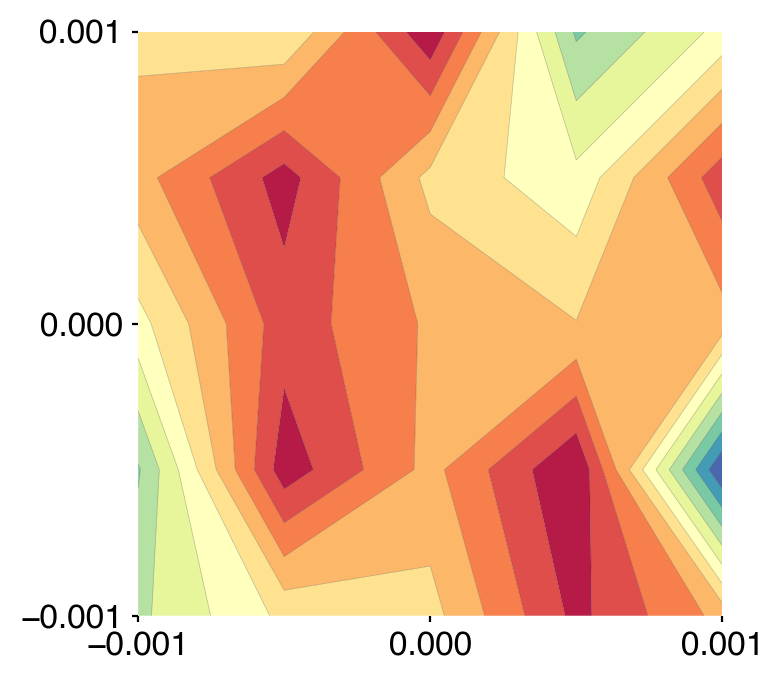

In [729]:
A = np.array(alphas)
B = np.array(betas)

X, Y = np.meshgrid(A, B, indexing='ij')

print('min =', loss_mat.min().item())
print('average =', loss_mat.mean().item())
print('max =', loss_mat.max().item())

levels = np.linspace(loss_mat.min(), loss_mat.max(), 12)

fig, ax = plt.subplots(figsize=(4, 4), dpi=200)

cf = ax.contourf(X, Y, loss_mat, levels=levels, cmap='Spectral', antialiased=True)
cs = ax.contour(X, Y, loss_mat, levels=levels, colors='k', linewidths=0.25, alpha=0.25)

ax.set_aspect('equal', adjustable='box')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=2)

amin, amax = A.min(), A.max()
bmin, bmax = B.min(), B.max()
amid = (amin + amax) / 2
bmid = (bmin + bmax) / 2

ax.set_xticks([amin, amid, amax])
ax.set_yticks([bmin, bmid, bmax])

tick_font = {'fontname': 'Helvetica', 'size': 12}
for xt in ax.get_xticklabels():
    xt.set_fontname(tick_font['fontname'])
    xt.set_fontsize(tick_font['size'])
for yt in ax.get_yticklabels():
    yt.set_fontname(tick_font['fontname'])
    yt.set_fontsize(tick_font['size'])

# title_font = {'fontname': 'Helvetica', 'size': 12, 'weight': 'bold'}
# ax.set_title(f"{model_title_name}, Contour map", **title_font)

png_path = os.path.join(lanscape_save_folder,
                        f"{dataset}_{task_name}_{target_model}_{alpha_min}-{alpha_max}_{beta_min}-{beta_max}_{grid_size}x{grid_size}.pdf")
plt.tight_layout()
plt.savefig(png_path)
plt.show()
plt.close(fig)

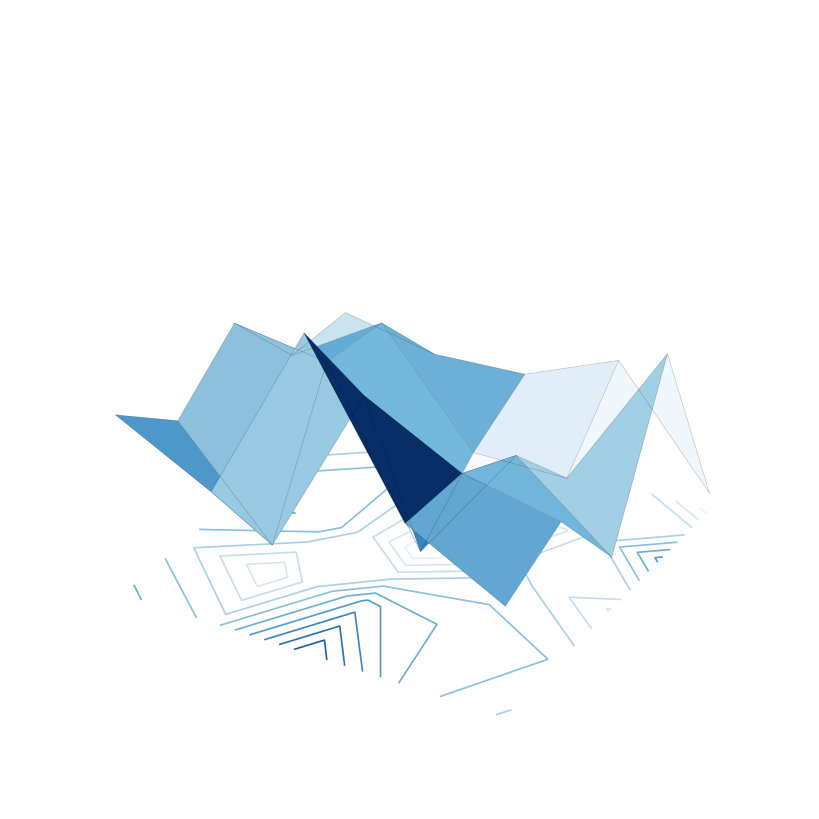

Saved 3D surface to: ../exp_results/landscape/filmtrust_fedrecgel-ns2e-2-sh0.00_epoch98.pth_-0.01-0.01_-0.01-0.01_5x5_3d.pdf


In [709]:
levels = np.linspace(loss_mat.min(), loss_mat.max(), 12)
cmap = plt.get_cmap('Blues')

fig = plt.figure(figsize=(5.2, 4.2), dpi=200)
ax = fig.add_subplot(111, projection='3d')

ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(loss_mat, cmap=cmap, vert_exag=1.0, blend_mode='soft')

surf = ax.plot_surface(
    X, Y, loss_mat,
    rstride=1, cstride=1,
    facecolors=rgb,
    cmap=cmap,
    linewidth=0, antialiased=True, shade=False
)

# --- (可选) 网格线/线框，帮助观察形状 ---
wf = ax.plot_wireframe(X, Y, loss_mat, rstride=max(1, len(A) // 20), cstride=max(1, len(B) // 20), color='k',
                       linewidth=0.2, alpha=0.25)

# --- (可选) 在底部平面做投影等高线，增强直观性 ---
zmin = float(loss_mat.min())
cset = ax.contour(
    X, Y, loss_mat, levels=levels, zdir='z', offset=zmin,
    cmap='Blues', linewidths=0.6, alpha=0.9
)

# 视角（俯仰 elev、方位 azim：可微调）
ax.view_init(elev=30, azim=-60)

ax.set_axis_off()
# 去掉外边框网格的“花纹”可选
# ax.xaxis.pane.fill = False
# ax.yaxis.pane.fill = False
# ax.zaxis.pane.fill = False

# mappable = plt.cm.ScalarMappable(cmap=cmap)
# mappable.set_array(loss_mat)
# cb = fig.colorbar(mappable, ax=ax, shrink=0.7, pad=0.08, aspect=18)
# cb.set_label('Loss')

# title_font = {'fontname': 'Helvetica', 'size': 12, 'weight': 'bold'}
# ax.set_title(f"{model_title_name}, Terrain map", **title_font)

plt.tight_layout()

# 保存
png_path_3d = os.path.join(lanscape_save_folder,
                           f"{dataset}_{task_name}_{target_model}_{alpha_min}-{alpha_max}_{beta_min}-{beta_max}_{grid_size}x{grid_size}_3d.pdf")
plt.savefig(png_path_3d, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"Saved 3D surface to: {png_path_3d}")

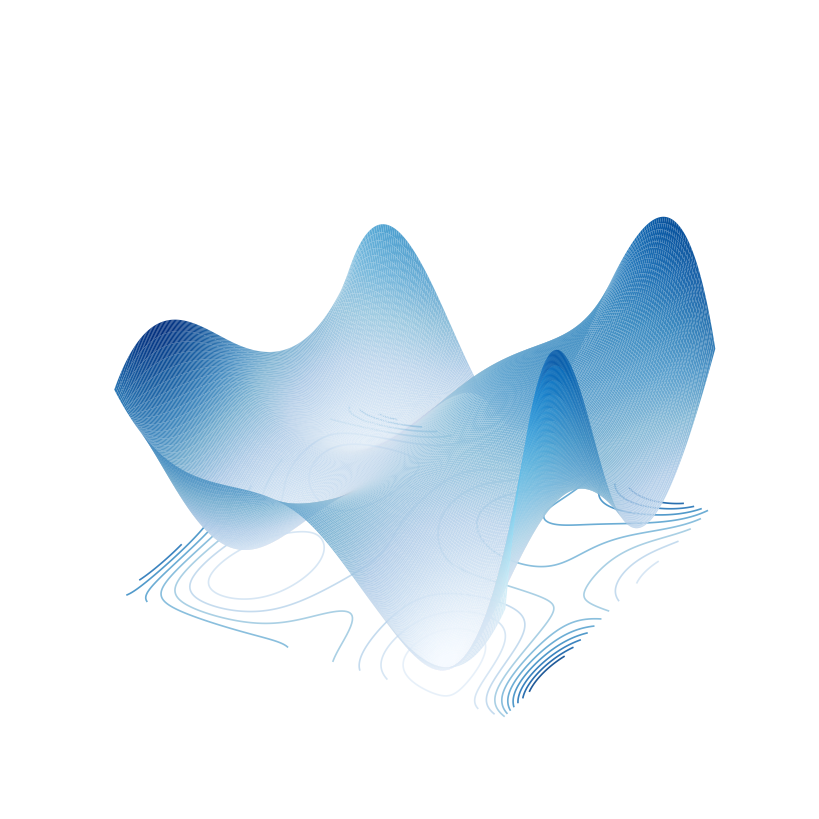

In [730]:
import numpy as np
from scipy.interpolate import RectBivariateSpline

# A, B 单调递增（若不是，请先排序并相应重排 loss_mat）
Ai = np.linspace(A.min(), A.max(), 200)   # 更密的横向网格
Bi = np.linspace(B.min(), B.max(), 200)   # 更密的纵向网格

# 样条插值：kx, ky 控制阶数（3=三次样条）
spline = RectBivariateSpline(A, B, loss_mat, kx=3, ky=3)

Xi, Yi = np.meshgrid(Ai, Bi, indexing='ij')
Zi = spline(Ai, Bi)   # 形状 (len(Ai), len(Bi))

# 用更密的 Zi 画图
levels = np.linspace(Zi.min(), Zi.max(), 12)
cmap = plt.get_cmap('Blues')

fig = plt.figure(figsize=(5.2, 4.2), dpi=200)
ax = fig.add_subplot(111, projection='3d')

from matplotlib.colors import LightSource
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(Zi, cmap=cmap, vert_exag=1.0, blend_mode='soft')

surf = ax.plot_surface(
    Xi, Yi, Zi,
    rstride=1, cstride=1,
    facecolors=rgb, cmap=cmap,
    linewidth=0, antialiased=True, shade=False
)

# （可选）去掉线框，让观感更“连续”
# ax.plot_wireframe(Xi, Yi, Zi, rstride=20, cstride=20, color='k', linewidth=0.2, alpha=0.15)

zmin = float(Zi.min())
ax.contour(Xi, Yi, Zi, levels=levels, zdir='z', offset=zmin, cmap='Blues', linewidths=0.6, alpha=0.9)

ax.view_init(elev=30, azim=-60)
ax.set_axis_off()
plt.tight_layout()

png_path_3d_smooth = os.path.join(lanscape_save_folder,
                           f"{dataset}_{task_name}_{target_model}_{alpha_min}-{alpha_max}_{beta_min}-{beta_max}_{grid_size}x{grid_size}_3d_smooth.pdf")

plt.savefig(png_path_3d_smooth, bbox_inches='tight')
plt.show()
plt.close(fig)
